# Resurgence in perturbation theory

Perturbative expansions in quantum theory typically have zero radius of convergence. Diagrammatically the reason is proliferation: the number of Feynman diagrams at order $n$ grows factorially. For the quartic anharmonic oscillator, Bender and Wu computed the coefficients explicitly and found growth like $n!\,3^n$.

The standard computational tool of modern physics thus produces, a series that converges nowhere. The claim of resurgence theory is that this can still be used, and that the divergence itself carries physical information. The growth rate of the coefficients is set by the actions of the instantons the expansion ignores; the ambiguity of resummation is the imaginary part of a physical decay rate; and the exact answer, non-perturbative effects included, can be reassembled from the perturbative coefficients alone.

This notebook walks through that claim on four examples:

1. **The Euler series** — why truncation has a floor, and what "non-perturbative" means quantitatively.
2. **The quartic anharmonic oscillator** $H = \tfrac{p^2}{2} + \tfrac{x^2}{2} + g\,x^4$ — the divergent Rayleigh–Schrödinger series is Borel-summed back to the true ground-state energy (checked against direct diagonalization), and at $g<0$ its resummation ambiguity *is* the decay width of the metastable vacuum.
3. **Zero-dimensional $\varphi^4$ theory** — the same structure in the simplest path integral, where everything can be checked by quadrature.
4. **The Airy function** — WKB across a turning point: the Stokes phenomenon, median summation, and the transseries.

In [ ]:
import Pkg; Pkg.activate(@__DIR__)
using Resurgence, CairoMakie, SpecialFunctions, LinearAlgebra
using QuadGK: quadgk
CairoMakie.activate!(type = "png")
set_theme!(theme_latexfonts(); fontsize = 15)

## 1. What perturbation theory cannot see

The standard first example is the Euler series

$$\Phi(\hbar) \;=\; \sum_{k\ge 0} k!\,(-\hbar)^{k+1} \;=\; -\hbar + \hbar^2 - 2\hbar^3 + 6\hbar^4 - \cdots,$$

the formal solution of $\hbar^2 \Phi' + \Phi = -\hbar$. The ODE has an actual solution, $-e^{1/\hbar} E_1(1/\hbar)$, but the series diverges for every $\hbar \neq 0$. The coefficients are stored as exact rationals:

In [2]:
Φ = FormalSeries(:euler, 40)

FormalSeries{Rational{BigInt}}: -ħ + ħ^2 - 2//1*ħ^3 + 6//1*ħ^4 - 24//1*ħ^5 + O(ħ^41)

Truncating at order $N$ works at first: the partial sums approach the exact value, up to an optimal order $N^* \approx 1/\hbar$, and then blow up factorially. The stars mark the optimal truncation found by `optimal_truncation`; the error there is of order $e^{-1/\hbar}$.

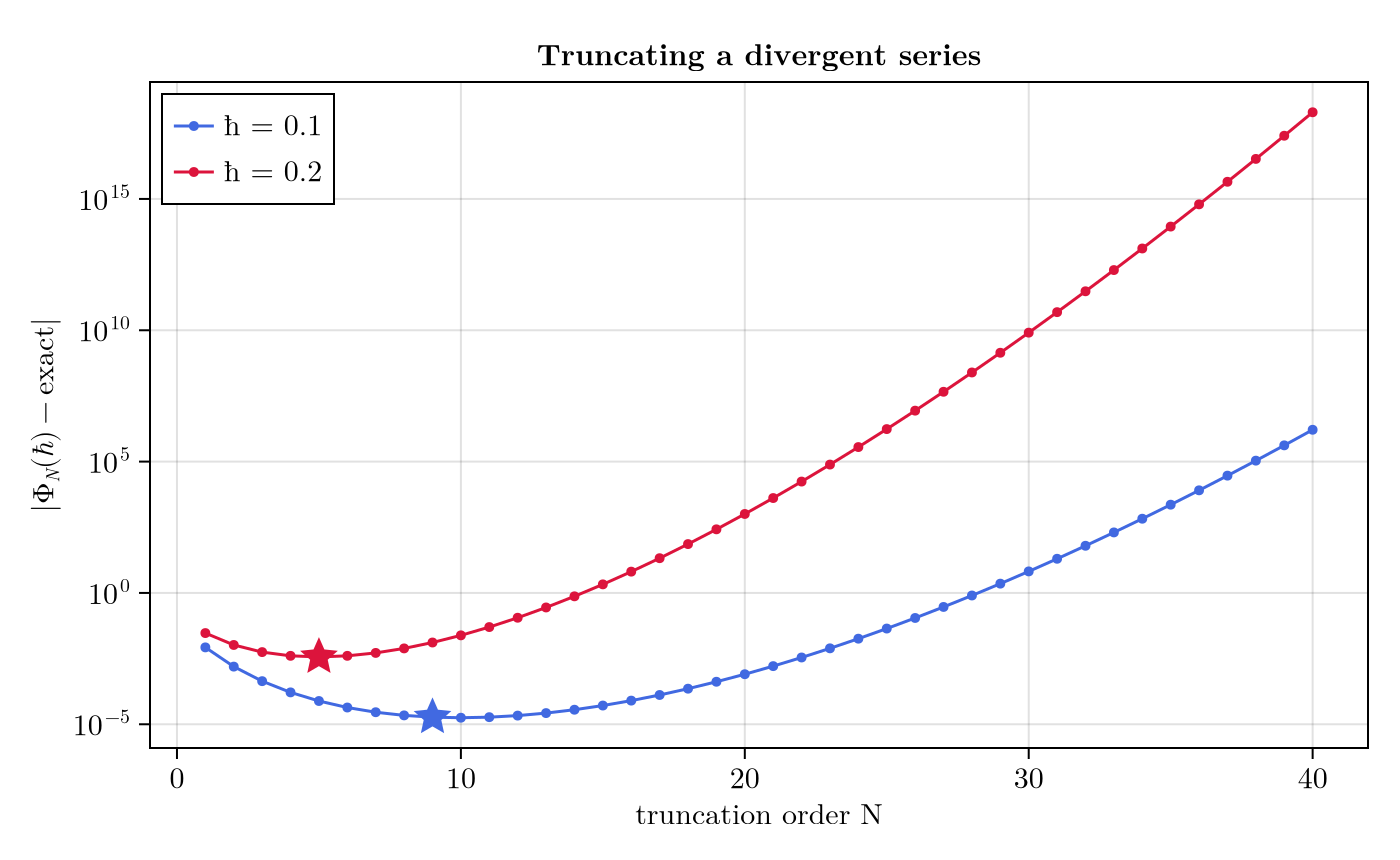

In [3]:
exact(ħ) = -exp(1/ħ) * expint(1/ħ)   # the Borel sum in closed form

fig = Figure(size = (700, 430))
ax = Axis(fig[1, 1]; yscale = log10, xlabel = "truncation order N",
          ylabel = L"|\Phi_N(\hbar) - \mathrm{exact}|",
          title = "Truncating a divergent series")
for (ħ, color) in ((0.1, :royalblue), (0.2, :crimson))
    errs = Float64.(abs.(partial_sums(Φ, ħ) .- exact(ħ)))
    scatterlines!(ax, eachindex(errs), errs; color, markersize = 7, label = "ħ = $ħ")
    opt = optimal_truncation(Φ, ħ)
    scatter!(ax, [opt.N], [Float64(abs(opt.value - exact(ħ)))];
             color, marker = :star5, markersize = 22)
end
axislegend(ax; position = :lt)
fig

This $e^{-1/\hbar}$ floor is the **superasymptotic limit**, and it is a physics statement: an instanton of action $A$ contributes effects of size $e^{-A/\hbar}$, which is *precisely* the size of the best truncation error. Whatever perturbation theory is truncated at — any order, any scheme — tunneling amplitudes, decay widths, and energy splittings are invisible below the wall. Seeing them requires resumming the series, not extending it.

## 2. Borel: dividing out the factorial

For $\Phi(\hbar) = \sum_n a_n\, \hbar^{n+\beta}$ the Borel transform

$$\hat{B}(\zeta) \;=\; \sum_{n} \frac{a_n}{\Gamma(n+\beta)}\, \zeta^{\,n+\beta-1}$$

divides out the factorial growth, so $\hat B$ has a finite radius of convergence, and the Laplace integral $\int_0^\infty e^{-\zeta/\hbar}\, \hat{B}(\zeta)\, d\zeta$ undoes it. The key fact: **the singularities of $\hat B$ are the actions of the problem.** Their distance from the origin sets the divergence rate of the $a_n$, and a singularity at $\zeta = A$ corresponds to effects of size $e^{-A/\hbar}$ — the Borel plane is a map of the non-perturbative content of the theory.

For the Euler series everything is known in closed form, $\hat{B}(\zeta) = -1/(1+\zeta)$: a single pole at $\zeta = -1$, off the positive axis, so the Laplace integral converges and reproduces $-e^{1/\hbar}E_1(1/\hbar)$ exactly. A $[1/1]$ Padé approximant of the (rational) transform captures it in exact arithmetic:

In [4]:
B = borel(Φ)
r = pade(B; order = 1)     # B̂ is exactly rational — a [1/1] Padé captures it fully
poles(r)

1-element Vector{Complex{BigFloat}}:
 -1.0 + 0.0im

## 3. The quartic anharmonic oscillator

Now the real thing: $H = \tfrac{p^2}{2} + \tfrac{x^2}{2} + g\,x^4$, the textbook interacting quantum system. Its ground-state energy has the Rayleigh–Schrödinger expansion (Bender–Wu 1969)

$$E_0(g) \;=\; \tfrac12 + \tfrac34\, g - \tfrac{21}{8}\, g^2 + \tfrac{333}{16}\, g^3 - \cdots,$$

computed here as exact rationals from the wavefunction recursion:

In [5]:
Φq = FormalSeries(:quartic, 60; var = :g)

FormalSeries{Rational{BigInt}}: 1//2 + 3//4*g - 21//8*g^2 + 333//16*g^3 - 30885//128*g^4 + O(g^60)

Where does this series diverge from? Look at its Borel plane:

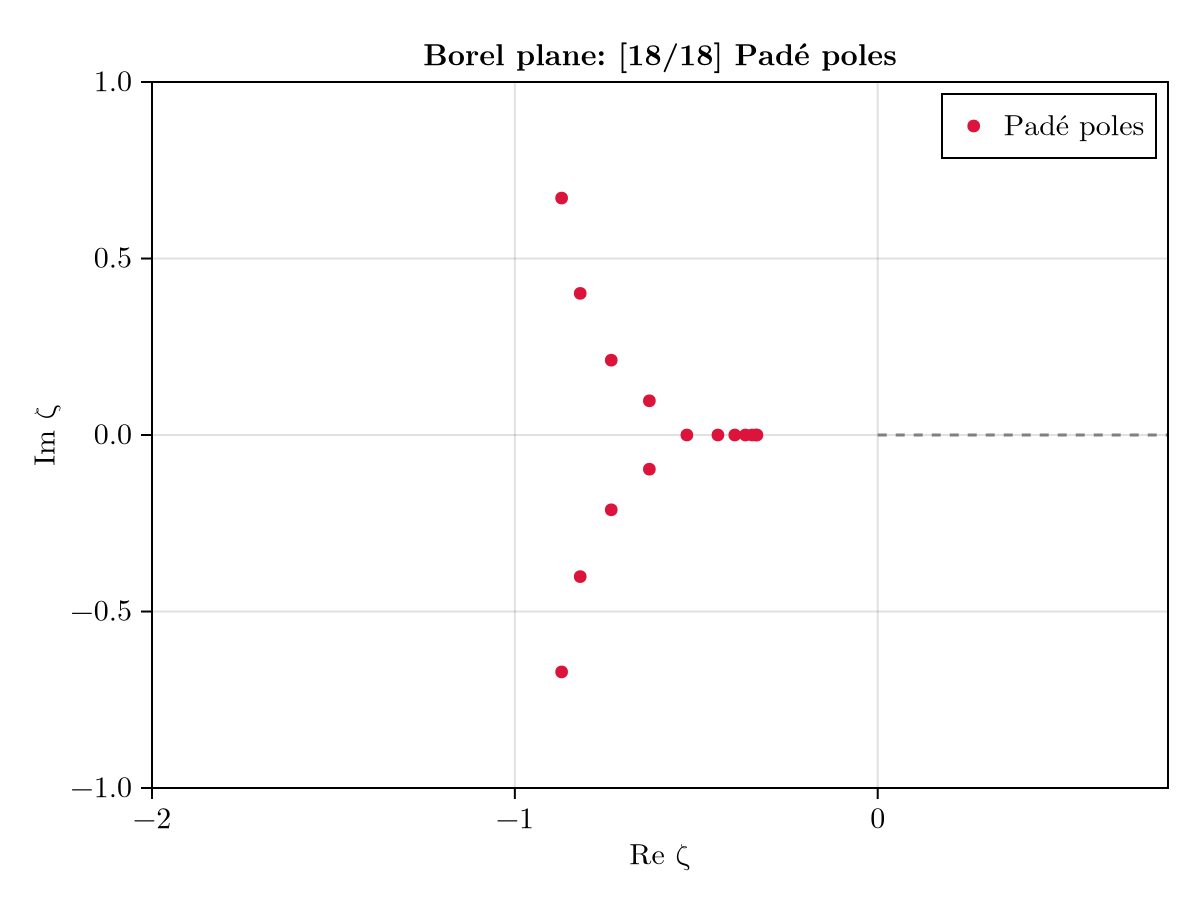

In [6]:
fig = plot_borel_plane(borel(Φq); order = 18)
xlims!(fig.content[1], -2.0, 0.8); ylims!(fig.content[1], -1.0, 1.0)   # zoom on the cut
fig

The Borel transform has a branch cut along $(-\infty, -1/3]$; the Padé approximant represents it by a string of real poles accumulating at the endpoint $\zeta = -1/3$ (the conjugate pairs off the axis are how it approximates the function away from the cut). The endpoint is no accident: $A = 1/3$ is the **action of the bounce** — the classical solution that tunnels out of the well when $g < 0$. The divergence of perturbation theory is caused by tunneling physics, and the Borel plane displays the responsible instanton, its action measured off the plot.

### Summing the series back to the Schrödinger equation

For physical coupling $g > 0$ the cut sits on the negative axis, the Laplace ray is clean, and the series is Borel summable. If the resummed series really *is* the ground-state energy, that can be checked against quantum mechanics done a completely different way: diagonalize $H$ in a truncated harmonic-oscillator basis, where $x = (a + a^\dagger)/\sqrt 2$ is tridiagonal.

In [7]:
function E0_diag(g; N = 300)
    X = Matrix(SymTridiagonal(zeros(N), sqrt.(1:N-1) ./ sqrt(2)))
    eigmin(Symmetric(Matrix(Diagonal((0:N-1) .+ 0.5)) + g * X^4))
end

println("  g      E₀ Borel-summed series   E₀ diagonalization    |difference|   best truncation error")
for g in (0.05, 0.1, 0.2)
    Eb = Float64(real(borel_sum(Φq, g; order = 18)))
    Ed = E0_diag(g)
    terr = Float64(abs(optimal_truncation(Φq, g).value - Ed))
    println(rpad(g, 7), rpad(Eb, 25), rpad(Ed, 22), rpad(round(abs(Eb - Ed), sigdigits = 3), 15),
            round(terr, sigdigits = 3))
end

  g      E₀ Borel-summed series   E₀ diagonalization    |difference|   best truncation error
0.05   0.5326427547718589       0.5326427547731969    1.34e-12       0.000507
0.1    0.5591463271835195       0.5591463271847559    1.24e-12       0.0104
0.2    0.6024051636862495       0.6024051636891894    2.94e-12       0.0476


The divergent series, resummed, *is* the spectrum — the agreement is limited by the eigensolver, not the series. Compare the last column: at $g = 0.2$ the optimal truncation stalls after $N^* = 2$ terms with a $\sim 5\%$ error, while the Borel sum of the *same sixty rational numbers* matches the Schrödinger equation to twelve digits. Precision follows the argument type — a `BigFloat` coupling returns more digits, limited only by the number of stored terms:

In [8]:
borel_sum(Φq, big"0.1"; order = 18)

0.5591463271835195766893459252380793704714583088715362402815334379778411237611096 + 0.0im

### The unstable vacuum: a decay width from real coefficients

Now make the coupling negative. The potential is unbounded below, the state in the well is metastable, and its energy acquires an imaginary part: $E_0 = \operatorname{Re} E_0 \mp i\,\Gamma/2$, with $\Gamma$ the tunneling decay rate. Where is $\Gamma$ in a series whose coefficients are all real?

For $g < 0$ the Laplace ray is $\theta = \pi$ — straight through the Borel cut. The package refuses to integrate through a singularity:

In [9]:
try
    laplace_sum(borel(Φq), -0.05; θ = π, order = 18)
catch e
    showerror(stdout, e)
end

PoleOnRay: Borel-plane pole at ζ ≈ -0.332858693738388 - 8.483185010312928e-232im lies on the Laplace ray θ = 3.141592653589793 (a Stokes ray); use `lateral_sum(B, ħ; side=:plus)` or `side=:minus` to integrate around it

That refusal is the physics: at $g<0$ the series is **not** Borel summable, and the obstruction carries the width. The two ways around the cut are the two lateral sums — the boundary values $E_0(g \pm i0)$ of the analytic continuation:

In [10]:
Bq = borel(Φq)
g = -0.05
s₊ = lateral_sum(Bq, g; θ = π, side = :plus,  order = 18)
s₋ = lateral_sum(Bq, g; θ = π, side = :minus, order = 18)
println("E₀(g + i0) = ", ComplexF64(s₊))
println("E₀(g − i0) = ", ComplexF64(s₋))
println("Γ/2 = |Im E₀| = ", Float64(abs(imag(s₊))))

E₀(g + i0) = 0.4503897240433143 - 0.0033284743509906342im
E₀(g − i0) = 0.4503897240433143 + 0.0033284743509906342im
Γ/2 = |Im E₀| = 0.0033284743509906342


Complex conjugates, as they must be: the real part (the resonance position) is unambiguous, the sign of the imaginary part records which side of the cut was chosen, and its magnitude is the half-width. The one-instanton prediction is

$$\frac{\Gamma}{2} \;\simeq\; \sqrt{\frac{2}{\pi |g|}}\; e^{-1/(3|g|)}\,\bigl(1 + O(g)\bigr),$$

with the action $1/3$ from the cut endpoint and the prefactor from the one-loop determinant around the bounce:

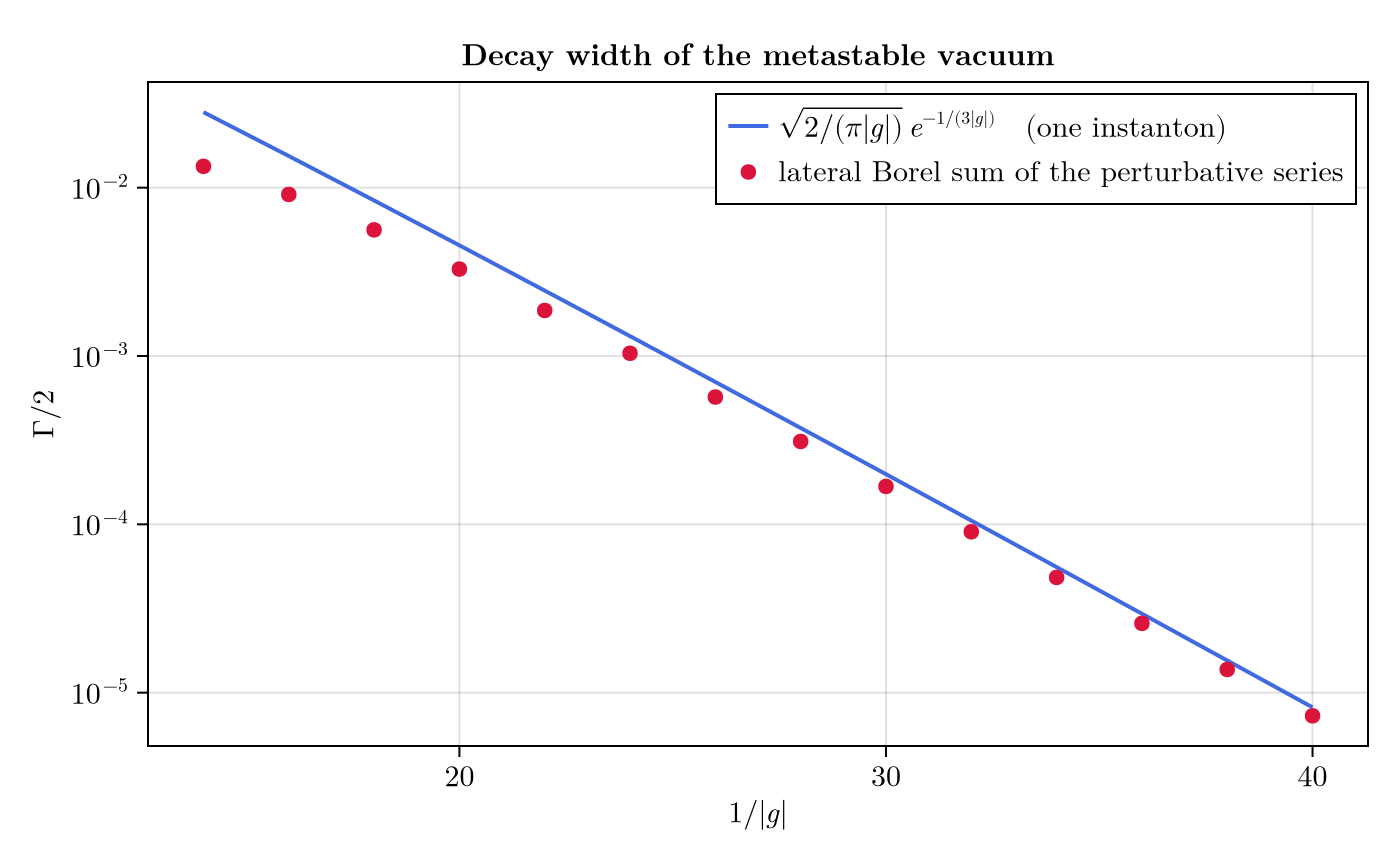

In [11]:
invg = range(14, 40; length = 14)
meas = [Float64(abs(imag(lateral_sum(Bq, -1/x; θ = π, side = :plus, order = 20)))) for x in invg]
pred = [sqrt(2x/π) * exp(-x/3) for x in invg]

fig = Figure(size = (700, 430))
ax = Axis(fig[1, 1]; yscale = log10, xlabel = L"1/|g|", ylabel = L"\Gamma/2",
          title = "Decay width of the metastable vacuum")
lines!(ax, invg, pred; color = :royalblue, linewidth = 2,
       label = L"\sqrt{2/(\pi|g|)}\, e^{-1/(3|g|)}\quad\mathrm{(one\ instanton)}")
scatter!(ax, invg, meas; color = :crimson, markersize = 11,
         label = "lateral Borel sum of the perturbative series")
axislegend(ax; position = :rt)
fig

Four decades of an exponentially small decay rate, read off from the perturbative coefficients. The visible offset is the $O(g)$ fluctuation correction around the bounce — the ratio tends to $1$ as $g \to 0^-$.

### Large order: the same instanton, a third time

A dispersion relation in the coupling closes the loop. $E_0(g)$ is analytic off the cut $g<0$, so

$$E_n \;=\; \frac{1}{\pi} \int_{-\infty}^{0} \frac{\operatorname{Im} E_0(g' + i0)}{g'^{\,n+1}}\, dg' ,$$

and for large $n$ the integral is dominated by $g' \to 0^-$ — the large-order coefficients are controlled by the *weak-coupling decay width just computed*. Inserting the one-instanton width gives the classic Bender–Wu asymptotics

$$E_n \;\sim\; -\frac{\sqrt 6}{\pi^{3/2}}\; (-3)^n\, \Gamma\!\left(n + \tfrac12\right)\!,$$

so the action is visible directly in the coefficient ratios:

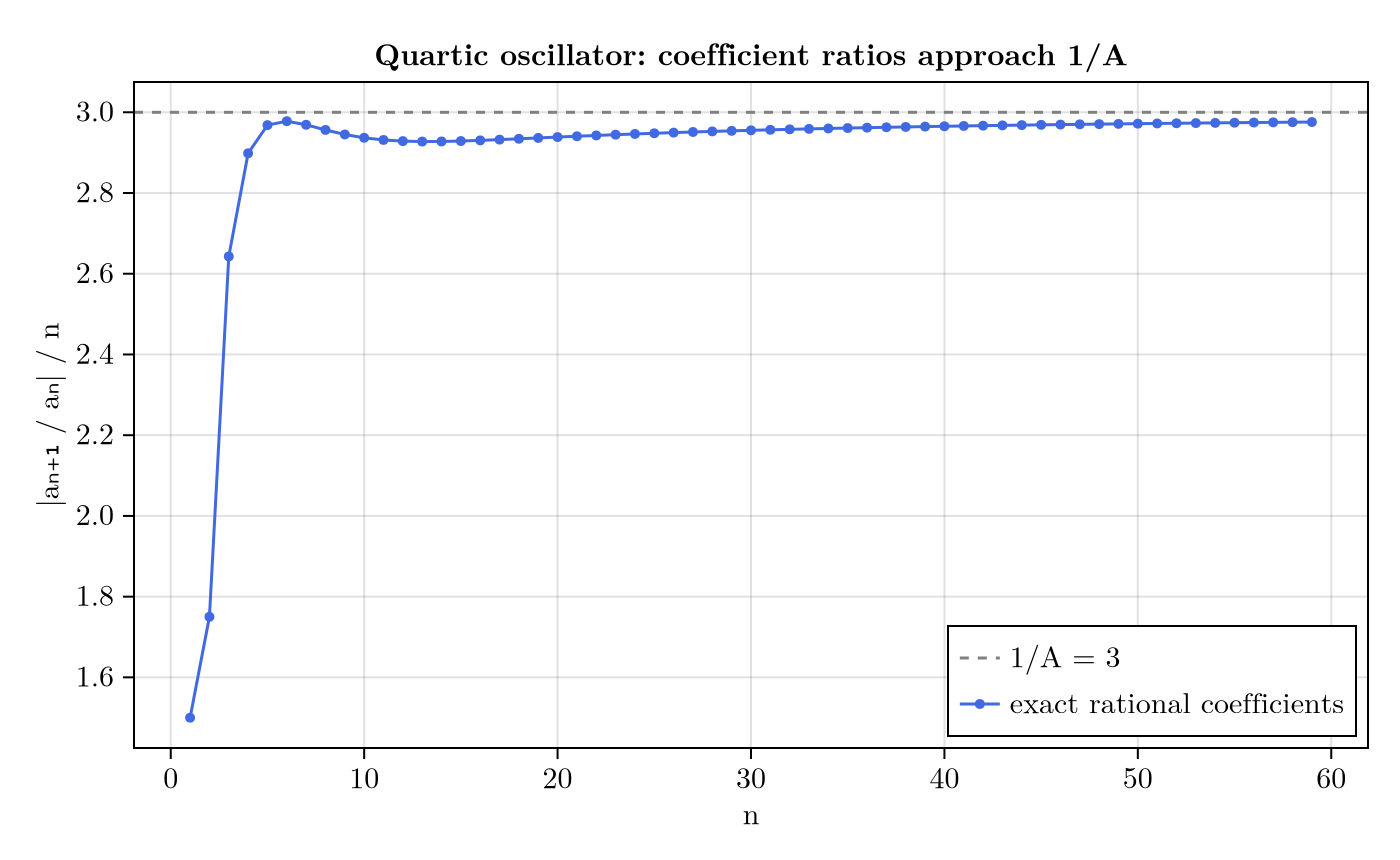

In [12]:
a = coefficients(Φq)
ratios = [Float64(abs(a[n+1] / a[n])) / n for n in 1:59]

fig = Figure(size = (700, 430))
ax = Axis(fig[1, 1]; xlabel = "n", ylabel = "|aₙ₊₁ / aₙ| / n",
          title = "Quartic oscillator: coefficient ratios approach 1/A")
hlines!(ax, [3.0]; color = :gray, linestyle = :dash, label = "1/A = 3")
scatterlines!(ax, 1:59, ratios; color = :royalblue, markersize = 7,
              label = "exact rational coefficients")
axislegend(ax; position = :rb)
fig

`large_order_fit` extrapolates all three parameters of $a_n \sim S\,\Gamma(n+b)/A^n$ (Richardson acceleration on the ratio sequences). The prefactor $S$ is the same number as the width prefactor, related through the dispersion relation by $\sqrt{2/\pi} = \pi |S| / \sqrt{3}$:

In [13]:
fit = large_order_fit(Φq; order = 8)
println("A = ", Float64(fit.A), "    exact: 1/3")
println("b = ", Float64(fit.b), "    exact: 1/2")
println("S = ", Float64(abs(fit.S)), "    exact: √6/π^(3/2) = ", sqrt(6) / π^1.5)
println()
println("width prefactor π|S|/√3 = ", Float64(π * abs(fit.S) / sqrt(3)),
        "    vs √(2/π) = ", sqrt(2/π))

A = 0.3333335876643971    exact: 1/3
b = 0.5003785861978978    exact: 1/2
S = 0.4389436881636492    exact: √6/π^(3/2) = 0.43989681358154537

width prefactor π|S|/√3 = 0.7961557825258497    vs √(2/π) = 0.7978845608028654


One instanton, seen three ways: as the endpoint of the Borel cut, as the decay width of the metastable vacuum, and as the growth rate of the perturbative coefficients. That triangle of relations — singularity ↔ discontinuity ↔ large order — is resurgence.

## 4. Zero-dimensional field theory

The smallest path integral,

$$Z(g) \;=\; \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} e^{-x^2/2 - g\,x^4}\, dx \;=\; \sum_{n \ge 0} \frac{(-1)^n\,(4n-1)!!}{n!}\; g^n ,$$

where the perturbative coefficients are obtained by expanding $e^{-gx^4}$ and Wick-contracting: the double factorial $(4n-1)!!$ *counts the vacuum Feynman diagrams* at order $n$. This is Dyson's divergence with the mechanism laid bare — diagrams proliferate factorially, so the series has zero radius of convergence, even though the integral is perfectly finite for $g > 0$. And the theory has an "instanton": the nontrivial saddle of $x^2/2 + g x^4$ at $x^2 = -1/(4g)$, with action $-1/(16g)$. The Borel singularity should therefore sit at $\zeta = -1/16$:

In [14]:
Zg = FormalSeries(:phi4, 40; var = :g)
ζs = poles(pade(borel(Zg); order = 12))
sort(ζs; by = abs)[1:4]    # cut endpoint → the saddle action −1/16 = −0.0625

4-element Vector{Complex{BigFloat}}:
 -0.06249918897504137731771007976874605432793538004841415318492479112760660185212429 - 1.305763625065601285371532779827457923916754727030385848276558272352622794786898e-317im
 -0.06498591128362545913976576238036519414712435354269839540243217926348866960243215 + 5.842179267453190368400226882115643592598827020126777519240264416840057102226298e-412im
 -0.06948608607380426451318905582961788017293400671105330230322009198744241558465019 - 1.223756357503943664514224694686048893146125614196973649585466696148710887040021e-393im
  -0.0767439891848683693742105038446034507903042031532093685283791174196110295649215 + 7.627864138137268024913666880605655448288170326179367330522908143420597479804358e-391im

Here every resurgence statement can be checked against direct quadrature of the integral:

In [15]:
for g in (0.1, 0.5, 2.0)
    exact, _ = quadgk(x -> exp(-x^2/2 - g*x^4) / sqrt(2π), -Inf, Inf)
    zb = Float64(real(borel_sum(Zg, g; order = 15)))
    println("g = $g:   quadrature = $exact   Borel sum = $zb   diff = ",
            round(abs(zb - exact), sigdigits = 3))
end

g = 0.1:   quadrature = 0.8576085853444098   Borel sum = 0.857608585345398   diff = 9.88e-13
g = 0.5:   quadrature = 0.6977279890519141   Borel sum = 0.697728034856066   diff = 4.58e-8
g = 2.0:   quadrature = 0.5439481448233605   Borel sum = 0.543962890964499   diff = 1.47e-5


Machine precision at weak coupling — and still five digits at $g = 2$, far outside any weak-coupling regime. The lesson that carries over to $d > 0$ dimensions: **the expansion around one saddle knows about the other saddles**, and the Borel plane is where they announce themselves. (In genuine QFT a second source of factorial growth appears, renormalons, whose Borel singularities are again "actions", of a different origin — same formalism, different physics.)

## 5. Airy: WKB across a turning point

The Airy equation $\psi'' = z\,\psi$ is Schrödinger with a linear potential — the universal model of a **turning point**, to which every smooth potential reduces locally. Its WKB expansion is the asymptotics of the Airy functions: with $\hbar = z^{-3/2}$ and $\xi = \tfrac{2}{3\hbar}$,

$$\mathrm{Bi}(z) \;\sim\; \frac{e^{\xi}}{\sqrt{\pi}\, z^{1/4}}\; \Psi(\hbar),$$

and the series $\Psi$ has its Borel singularity at $\zeta = +4/3$ — the action connecting the two WKB branches — sitting **on** the Laplace ray. Unlike the oscillator at $g<0$, there is no physical deformation that moves it: this is the Stokes-line configuration, and the two lateral sums differ:

In [16]:
Ψ = FormalSeries(:airy_bi, 40)
Bψ = borel(Ψ)
s₊ = lateral_sum(Bψ, 0.3; side = :plus,  order = 10)
s₋ = lateral_sum(Bψ, 0.3; side = :minus, order = 10)
println("s₊ = ", ComplexF64(s₊))
println("s₋ = ", ComplexF64(s₋))

s₊ = 1.0447747467082065 + 0.005719805307169453im
s₋ = 1.0447747467082065 - 0.005719805307169453im


The series has real coefficients, yet the two sums carry opposite exponentially small imaginary parts — the **Stokes phenomenon**, the resummation ambiguity of WKB. Neither lateral sum is Bi; the real answer is the median summation, and it agrees with the actual Airy function:

In [17]:
ħ = 0.3;  z = ħ^(-2/3);  ξ = 2/(3ħ)
med = median_sum(Ψ, ħ; order = 10)
ref = sqrt(π) * z^(1/4) * exp(-ξ) * airybi(z)     # SpecialFunctions' Bi(z)
println("median sum      = ", ComplexF64(med))
println("from airybi(z)  = ", ref)
println("relative error  = ", Float64(abs(med - ref) / ref))

median sum      = 1.0447747467082065 + 0.0im
from airybi(z)  = 1.0447747467467672
relative error  = 3.6908185592780766e-11


The discontinuity itself is fixed by resurgence:

$$s_+ - s_- \;=\; -S_1\, e^{-A/\hbar}\; s\big(\Phi_{\mathrm{Ai}}\big)(\hbar),$$

where $\Phi_{\mathrm{Ai}}$ is the *other* Airy series — the one-instanton sector of the Airy transseries — and the Stokes constant has $|S_1| = 1$. This is the WKB **connection formula** in resurgent form: the jump of the dominant solution across the Stokes line is the subdominant solution. Both sides can be computed independently here — the jump of one divergent series against the Borel sum of another:

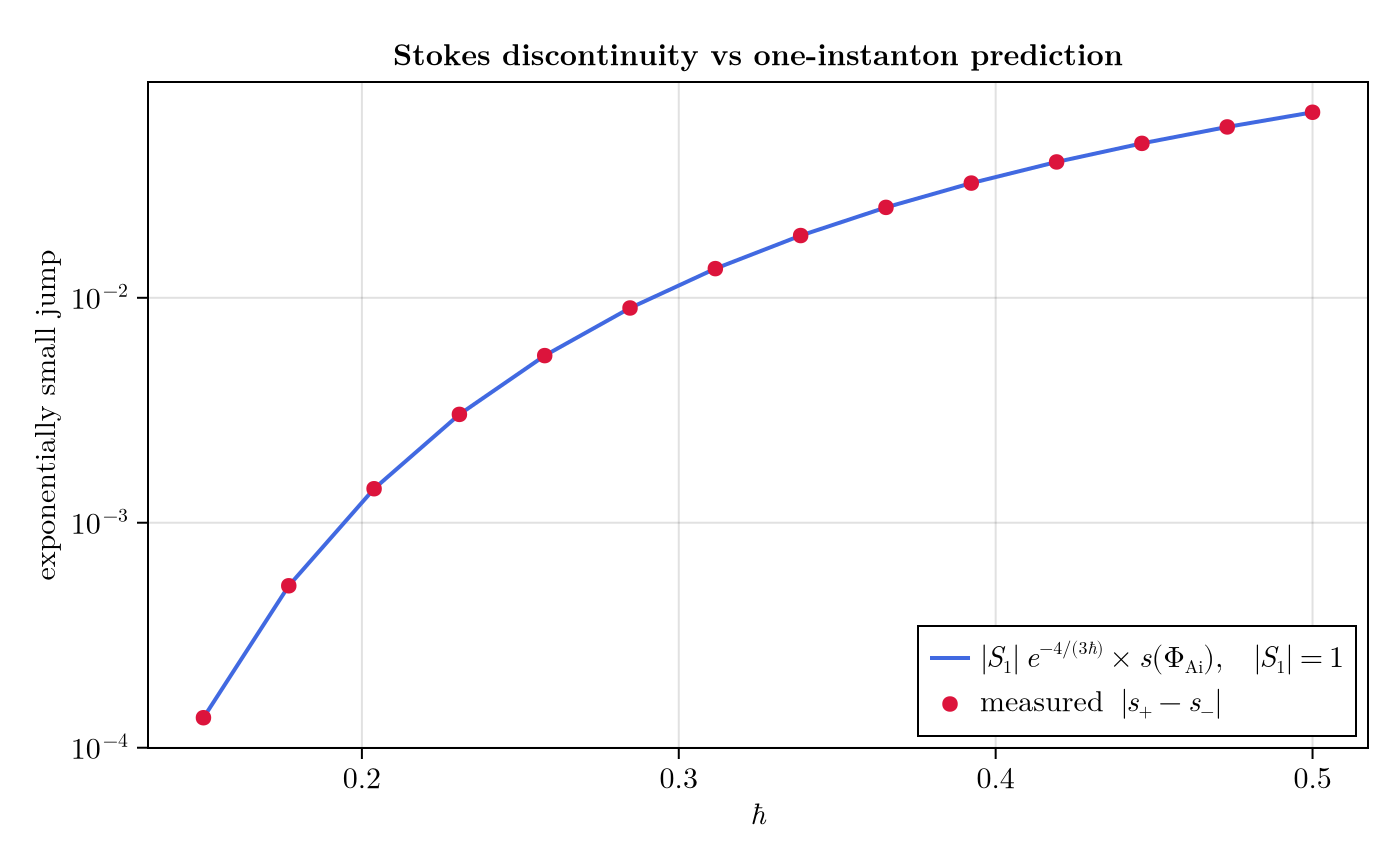

In [18]:
Φₐ = FormalSeries(:airy, 40)     # the Ai series: Borel pole at −4/3, ℝ₊ is clean
ħs = range(0.15, 0.5; length = 14)
disc = [Float64(abs(stokes_discontinuity(Bψ, h; order = 10))) for h in ħs]
pred = [exp(-4/(3h)) * Float64(abs(borel_sum(Φₐ, h; order = 10))) for h in ħs]

fig = Figure(size = (700, 430))
ax = Axis(fig[1, 1]; yscale = log10, xlabel = L"\hbar", ylabel = "exponentially small jump",
          title = "Stokes discontinuity vs one-instanton prediction")
lines!(ax, ħs, pred; color = :royalblue, linewidth = 2,
       label = L"|S_1|\, e^{-4/(3\hbar)} \times s(\Phi_{\mathrm{Ai}}),\quad |S_1| = 1")
scatter!(ax, ħs, disc; color = :crimson, markersize = 11,
         label = L"\mathrm{measured}\;\; |s_+ - s_-|")
axislegend(ax; position = :rb)
fig

In the language of **alien calculus** the statement is structural: the alien derivative — the operator measuring the singularity of a series at the action $A$ — maps one sector of the transseries to the next, $\Delta_A\, \Phi_{\mathrm{Ai}} = S_1\, \Phi_{\mathrm{Bi}}$. Each WKB series contains its sibling, coefficient by coefficient, inside its Borel singularity. The package computes this exactly on the Airy transseries, and the Stokes constant follows from two independent routes:

In [19]:
T = Transseries(:airy, 12)
D = alien_derivative(T; stokes = im)      # Δ_A (Φ_Ai + σ e^{−A/ħ} Φ_Bi)
println("Δ_A maps the Ai sector to S₁ × the Bi series (exactly): ",
        coefficients(sector(D, 0)) == im * coefficients(FormalSeries(:airy_bi, 12)))
println()
println("residue route     : |S₁| = ", Float64(abs(stokes_constant(Bψ; order = 10))))
println("large-order route : |S₁| = ", Float64(stokes_constant(Φₐ; order = 6)))

Δ_A maps the Ai sector to S₁ × the Bi series (exactly): true

residue route     : |S₁| = 0.9969477065764087
large-order route : |S₁| = 1.0000000021331596
